# **PROJECT 02**

In [ ]:
import pandas as pd

df = pd.read_csv("train.csv")

print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

df.head()

Shape: (1460, 81)

Data Types:
Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object

Missing Values:
Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

Duplicate Rows: 0


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# **Dataset Summary**
1. The dataset contains 1460 residential properties with 81 attributes.
2. The target variable is SalePrice, which represents the selling price of a house.
3. Features include property size, location, quality, age, garage details, and amenities.
4. The dataset contains both numerical and categorical variables.
5. Several columns contain missing values and will require preprocessing before model training.

In [ ]:
df.info()
df.isnull().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [ ]:
missing_values = df.isnull().sum().sort_values(ascending=False)
print(missing_values[missing_values > 0])

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [ ]:
drop_cols=['PoolQC', 'MiscFeature', 'Alley', 'Fence']
df.drop(columns=drop_cols, inplace=True)

In [ ]:
none_cols= [ 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure',
    'BsmtFinType1', 'BsmtFinType2']
for col in none_cols:
  df[col] = df[col].fillna('None')

In [ ]:
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['GarageYrBlt'].median())
df['MasVnrArea'] = df['MasVnrArea'].fillna(df['MasVnrArea'].median())

In [ ]:
df['MasVnrType'] = df['MasVnrType'].fillna(df['MasVnrType'].mode()[0])
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

In [ ]:
print(df.isnull().sum().sum())

0


**Data Preprocessing Summary**

1. Dropped PoolQC, MiscFeature, Alley, and Fence because more than 70% of their values were missing.
2. Filled basement, garage, and fireplace-related missing values with 'None' because missing values indicate absence of that feature.
3. Filled numerical columns (LotFrontage, GarageYrBlt, MasVnrArea) using median values to reduce the impact of outliers.
4. Filled categorical columns (MasVnrType, Electrical) using the mode because they contained very few missing values.
5. After preprocessing, the dataset contained no missing values.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
corr = df.corr(numeric_only=True)
top_corr = corr['SalePrice'].sort_values(ascending=False)
print(top_corr.head(15))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
MasVnrArea      0.472614
Fireplaces      0.466929
GarageYrBlt     0.466754
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


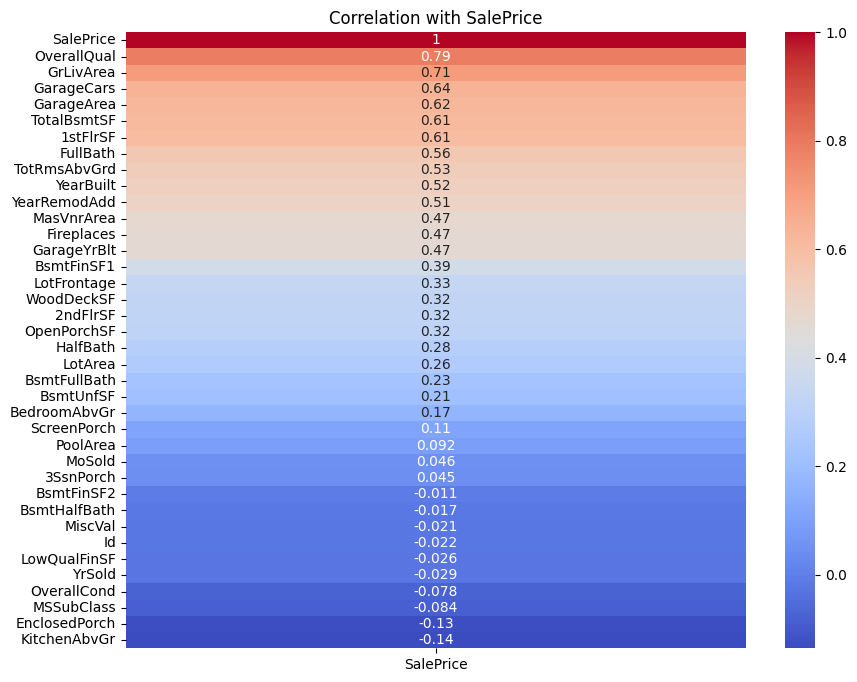

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(
    corr[['SalePrice']].sort_values(by='SalePrice', ascending=False),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation with SalePrice')
plt.show()

Feature Engineering Observation:

OverallQual, GrLivArea, GarageCars, GarageArea and TotalBsmtSF showed the strongest positive correlation with SalePrice. These features were considered important predictors because they directly represent house quality, size and utility.

1. The overall quality of a house is the strongest predictor of its selling price. Houses with better construction quality and finishes tend to have significantly higher prices.
2. Larger living areas generally lead to higher selling prices, indicating that house size strongly influences market value.
3. Properties with larger garages and greater parking capacity tend to be more expensive.
4. Houses with larger basement and first-floor areas generally command higher prices.
5. Newer and recently renovated homes tend to sell at higher prices compared to older properties.

In [11]:
df_encoded = pd.get_dummies(df, drop_first=True)

print("Original Shape:", df.shape)
print("Encoded Shape:", df_encoded.shape)

Original Shape: (1460, 77)
Encoded Shape: (1460, 247)


In [12]:
X = df_encoded.drop("SalePrice", axis=1)
y = df_encoded["SalePrice"]
print(X.shape)
print(y.shape)

(1460, 246)
(1460,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1168, 246)
(292, 246)


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

lr = LinearRegression()
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(random_state=42)

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

Three regression algorithms were trained and compared:
1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor

These models were selected to compare linear, tree based, and ensemble learning approaches for house price prediction.

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np
models = {
    "Linear Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf
}
results = []
for name, model in models.items():
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append([name, mae, rmse, r2])

comparison = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R² Score"]
)

comparison.sort_values(by="R² Score", ascending=False)

,Model,MAE,RMSE,R² Score
2,Random Forest,17621.326301,29089.243474,0.889681
1,Decision Tree,27395.352740,43103.002726,0.757785
0,Linear Regression,20607.582950,52614.109588,0.639097


Among all three models, Random Forest achieved the best performance with the lowest MAE (17,621), lowest RMSE (29,089), and highest R² score (0.89). This indicates that Random Forest was able to capture complex relationships between house features and sale prices more effectively than Linear Regression and Decision Tree models.

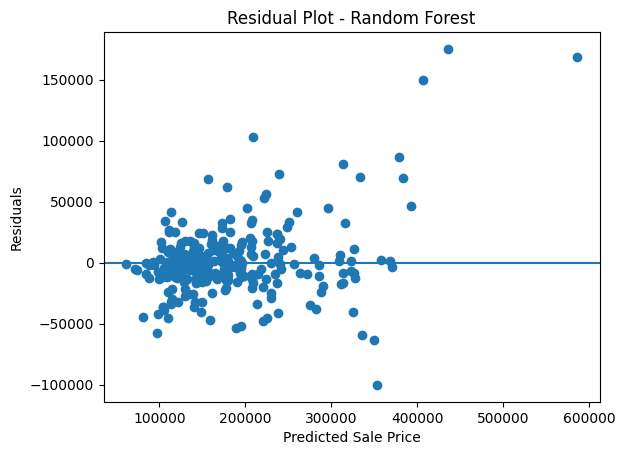

In [20]:
import matplotlib.pyplot as plt

rf_pred = rf.predict(X_test)
residuals = y_test - rf_pred
plt.scatter(rf_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Sale Price")
plt.ylabel("Residuals")
plt.title("Residual Plot - Random Forest")
plt.show()

The residual plot shows that most prediction errors are randomly distributed around the zero line, indicating that the Random Forest model does not exhibit significant bias. While a few larger errors are present for high-priced houses, the overall distribution suggests that the model captures the relationship between house features and sale prices effectively.

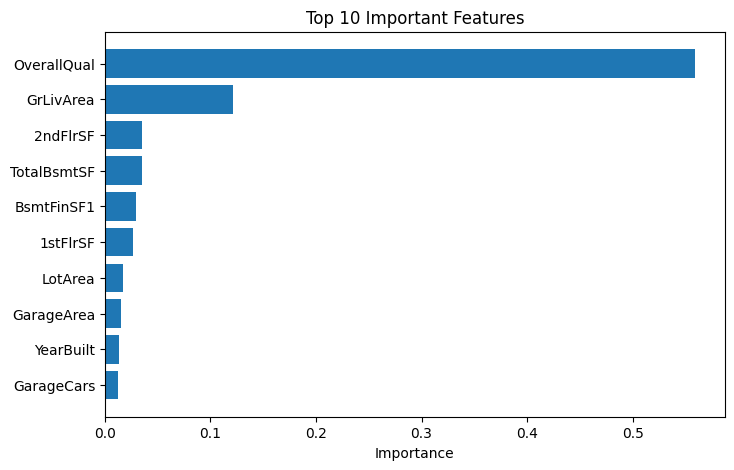

        Feature  Importance
4   OverallQual    0.559345
16    GrLivArea    0.121403
14     2ndFlrSF    0.035226
12  TotalBsmtSF    0.034979
9    BsmtFinSF1    0.029721
13     1stFlrSF    0.026947
3       LotArea    0.016772
27   GarageArea    0.015748
6     YearBuilt    0.013090
26   GarageCars    0.012588


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

plt.figure(figsize=(8,5))
plt.barh(importance['Feature'], importance['Importance'])
plt.title('Top 10 Important Features')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()

print(importance)

# **5 Line Conclusion**
1. The dataset was successfully preprocessed by handling missing values and encoding categorical variables.
2. Correlation analysis showed that OverallQual, GrLivArea, GarageCars, and TotalBsmtSF were among the most influential features affecting house prices.
3. Three machine learning models were trained and evaluated: Linear Regression, Decision Tree Regressor, and Random Forest Regressor.
4. Random Forest achieved the best performance with an R² score of 0.89 and the lowest prediction errors.
5. Therefore, Random Forest was selected as the final model for house price prediction due to its superior accuracy and ability to capture complex feature relationships.